# Tarea 02: Vectorización y análisis de sentimiento de reseñas de hoteles
## Autor: Alejandra Paola Castillo Gallegos

In [1]:
# Librerias

!pip -q install nltk wordcloud

import re, json, warnings
from pathlib import Path
from collections import Counter
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from wordcloud import WordCloud
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer
from nltk.sentiment import SentimentIntensityAnalyzer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, classification_report,
                             confusion_matrix, ConfusionMatrixDisplay,
                             precision_recall_fscore_support)
from scipy.sparse.linalg import norm as sparse_norm
from google.colab import files

warnings.filterwarnings("ignore")
pd.set_option("display.max_colwidth", 250)
for recurso in ["punkt", "punkt_tab", "stopwords", "wordnet", "omw-1.4", "vader_lexicon"]:
    nltk.download(recurso, quiet=True)
print("Bibliotecas cargadas correctamente.")

Bibliotecas cargadas correctamente.


In [2]:
# Carga de datos

archivos_subidos = files.upload()
archivos_csv = [n for n in archivos_subidos if n.lower().endswith(".csv")]
if not archivos_csv:
    raise FileNotFoundError("No se cargó un archivo CSV.")
ruta_csv = archivos_csv[0]
try:
    df = pd.read_csv(ruta_csv)
except UnicodeDecodeError:
    df = pd.read_csv(ruta_csv, encoding="latin-1")
print(f"Archivo: {ruta_csv}")
print(f"Dimensiones originales: {df.shape}")
display(df.head())

Saving tripadvisor_hotel_reviews.csv to tripadvisor_hotel_reviews (1).csv
Archivo: tripadvisor_hotel_reviews (1).csv
Dimensiones originales: (20491, 2)


,Review,Rating
0,"nice hotel expensive parking got good deal stay hotel anniversary, arrived late evening took advice previous reviews did valet parking, check quick easy, little disappointed non-existent view room room clean nice size, bed comfortable woke stiff ...",4
1,"ok nothing special charge diamond member hilton decided chain shot 20th anniversary seattle, start booked suite paid extra website description not, suite bedroom bathroom standard hotel room, took printed reservation desk showed said things like ...",2
2,"nice rooms not 4* experience hotel monaco seattle good hotel n't 4* level.positives large bathroom mediterranean suite comfortable bed pillowsattentive housekeeping staffnegatives ac unit malfunctioned stay desk disorganized, missed 3 separate wa...",3
3,"unique, great stay, wonderful time hotel monaco, location excellent short stroll main downtown shopping area, pet friendly room showed no signs animal hair smells, monaco suite sleeping area big striped curtains pulled closed nice touch felt cosy...",5
4,"great stay great stay, went seahawk game awesome, downfall view building did n't complain, room huge staff helpful, booked hotels website seahawk package, no charge parking got voucher taxi, problem taxi driver did n't want accept voucher barely ...",5


In [3]:
# Identificaión y validación de columnas

columnas = {str(col).strip().lower(): col for col in df.columns}
texto_opciones = ["review", "reviews", "text", "review_text", "content"]
rating_opciones = ["rating", "ratings", "score", "stars", "star_rating"]
col_texto = next((columnas[x] for x in texto_opciones if x in columnas), None)
col_rating = next((columnas[x] for x in rating_opciones if x in columnas), None)
if col_texto is None or col_rating is None:
    raise ValueError(f"No se identificaron Review y Rating. Columnas: {list(df.columns)}")
df = df[[col_texto, col_rating]].copy()
df.columns = ["Review", "Rating"]
df["Rating"] = pd.to_numeric(df["Rating"], errors="coerce")
print("Columnas identificadas:", col_texto, "y", col_rating)
display(df.head())

Columnas identificadas: Review y Rating


,Review,Rating
0,"nice hotel expensive parking got good deal stay hotel anniversary, arrived late evening took advice previous reviews did valet parking, check quick easy, little disappointed non-existent view room room clean nice size, bed comfortable woke stiff ...",4
1,"ok nothing special charge diamond member hilton decided chain shot 20th anniversary seattle, start booked suite paid extra website description not, suite bedroom bathroom standard hotel room, took printed reservation desk showed said things like ...",2
2,"nice rooms not 4* experience hotel monaco seattle good hotel n't 4* level.positives large bathroom mediterranean suite comfortable bed pillowsattentive housekeeping staffnegatives ac unit malfunctioned stay desk disorganized, missed 3 separate wa...",3
3,"unique, great stay, wonderful time hotel monaco, location excellent short stroll main downtown shopping area, pet friendly room showed no signs animal hair smells, monaco suite sleeping area big striped curtains pulled closed nice touch felt cosy...",5
4,"great stay great stay, went seahawk game awesome, downfall view building did n't complain, room huge staff helpful, booked hotels website seahawk package, no charge parking got voucher taxi, problem taxi driver did n't want accept voucher barely ...",5


In [4]:
# Limpieza de datos

print("Valores faltantes:")
display(df.isna().sum().to_frame("faltantes"))
print("Reseñas duplicadas:", df.duplicated(subset=["Review"]).sum())
display(df["Rating"].describe().to_frame().T)

df = df.dropna(subset=["Review", "Rating"]).copy()
df = df.drop_duplicates(subset=["Review"]).copy()
df = df[df["Rating"].between(1, 5)].copy()
df["Review"] = df["Review"].astype(str).str.strip()
df = df[df["Review"].str.len() > 0].reset_index(drop=True)
print(f"Dimensiones depuradas: {df.shape}")

Valores faltantes:


,faltantes
Review,0
Rating,0


Reseñas duplicadas: 0


,count,mean,std,min,25%,50%,75%,max
Rating,20491.0,3.952223,1.23303,1.0,3.0,4.0,5.0,5.0


Dimensiones depuradas: (20491, 2)


In [5]:
# Análisis exploratorio

df["numero_caracteres"] = df["Review"].str.len()
df["numero_palabras"] = df["Review"].str.split().str.len()
display(df[["numero_caracteres", "numero_palabras"]].describe().round(2))

,numero_caracteres,numero_palabras
count,20491.0,20491.00
mean,722.9,104.38
std,689.1,100.66
min,42.0,7.00
25%,337.0,48.00
50%,535.0,77.00
75%,857.0,124.00
max,13499.0,1931.00


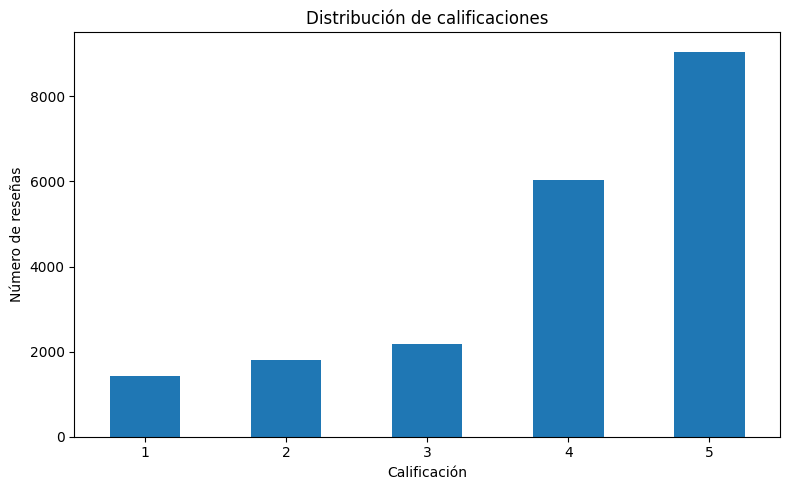

,frecuencia
Rating,
1,1421
2,1793
3,2184
4,6039
5,9054


In [6]:
conteo_rating = df["Rating"].value_counts().sort_index()
plt.figure(figsize=(8,5))
conteo_rating.plot(kind="bar")
plt.title("Distribución de calificaciones")
plt.xlabel("Calificación"); plt.ylabel("Número de reseñas")
plt.xticks(rotation=0); plt.tight_layout(); plt.show()
display(conteo_rating.rename("frecuencia").to_frame())

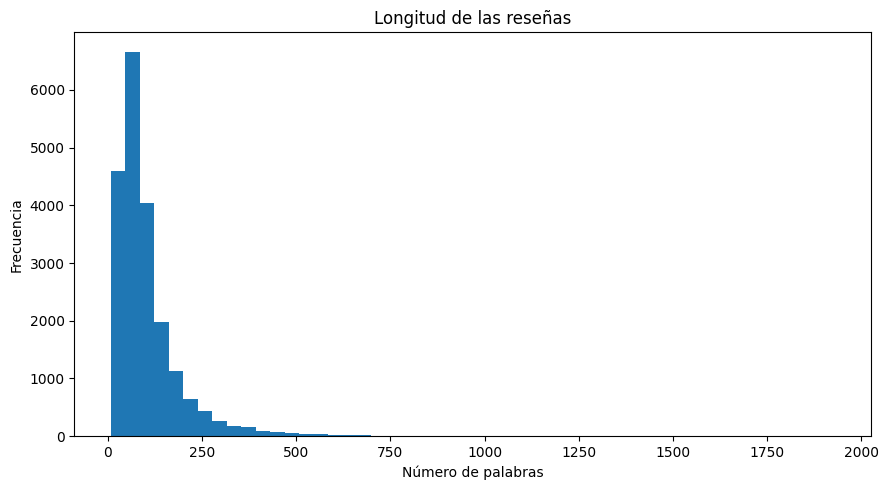

In [7]:
plt.figure(figsize=(9,5))
plt.hist(df["numero_palabras"], bins=50)
plt.title("Longitud de las reseñas")
plt.xlabel("Número de palabras"); plt.ylabel("Frecuencia")
plt.tight_layout(); plt.show()

,frecuencia,porcentaje
sentimiento_rating,,
Negativo,3214,15.68
Neutral,2184,10.66
Positivo,15093,73.66


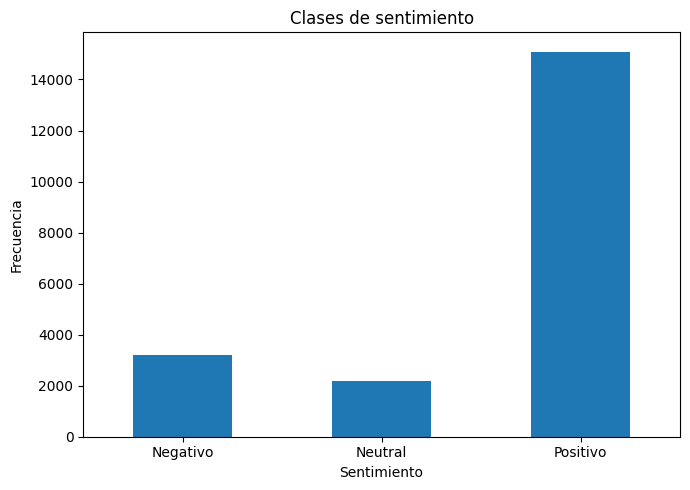

In [8]:
# Sentimiento derivado de la calificación
## - 1–2 estrellas: Negativo
## - 3 estrellas: Neutral
## - 4–5 estrellas: Positivo

def clasificar_sentimiento_rating(rating):
    if rating <= 2:
        return "Negativo"
    if rating == 3:
        return "Neutral"
    return "Positivo"

df["sentimiento_rating"] = df["Rating"].apply(clasificar_sentimiento_rating)
orden_clases = ["Negativo", "Neutral", "Positivo"]
resumen_clases = pd.DataFrame({
    "frecuencia": df["sentimiento_rating"].value_counts().reindex(orden_clases).fillna(0).astype(int),
    "porcentaje": df["sentimiento_rating"].value_counts(normalize=True).reindex(orden_clases).fillna(0).mul(100).round(2)
})
display(resumen_clases)
plt.figure(figsize=(7,5)); resumen_clases["frecuencia"].plot(kind="bar")
plt.title("Clases de sentimiento"); plt.xlabel("Sentimiento"); plt.ylabel("Frecuencia")
plt.xticks(rotation=0); plt.tight_layout(); plt.show()

In [10]:
# Procesamiento del texto
# Se convierten las reseñas a minúsculas, se eliminan HTML, URL y símbolos, se tokenizan, se eliminan palabras vacías y se lematiza. Se quedan negaciones como NOT, NO y NEVER.

stop_words = set(stopwords.words("english")) - {"no", "not", "nor", "never"}
lematizador = WordNetLemmatizer()

def limpiar_texto(texto):
    texto = str(texto).lower()
    texto = re.sub(r"<[^>]+>", " ", texto)
    texto = re.sub(r"http\S+|www\.\S+", " ", texto)
    texto = re.sub(r"[^a-z\s]", " ", texto)
    texto = re.sub(r"\s+", " ", texto).strip()
    tokens = word_tokenize(texto)
    tokens = [lematizador.lemmatize(t) for t in tokens if t not in stop_words and len(t) > 1]
    return " ".join(tokens)

df["texto_limpio"] = df["Review"].apply(limpiar_texto)
df = df[df["texto_limpio"].str.len() > 0].reset_index(drop=True)
display(df[["Review", "texto_limpio"]].head())

,Review,texto_limpio
0,"nice hotel expensive parking got good deal stay hotel anniversary, arrived late evening took advice previous reviews did valet parking, check quick easy, little disappointed non-existent view room room clean nice size, bed comfortable woke stiff ...",nice hotel expensive parking got good deal stay hotel anniversary arrived late evening took advice previous review valet parking check quick easy little disappointed non existent view room room clean nice size bed comfortable woke stiff neck high...
1,"ok nothing special charge diamond member hilton decided chain shot 20th anniversary seattle, start booked suite paid extra website description not, suite bedroom bathroom standard hotel room, took printed reservation desk showed said things like ...",ok nothing special charge diamond member hilton decided chain shot th anniversary seattle start booked suite paid extra website description not suite bedroom bathroom standard hotel room took printed reservation desk showed said thing like tv cou...
2,"nice rooms not 4* experience hotel monaco seattle good hotel n't 4* level.positives large bathroom mediterranean suite comfortable bed pillowsattentive housekeeping staffnegatives ac unit malfunctioned stay desk disorganized, missed 3 separate wa...",nice room not experience hotel monaco seattle good hotel level positive large bathroom mediterranean suite comfortable bed pillowsattentive housekeeping staffnegatives ac unit malfunctioned stay desk disorganized missed separate wakeup call conci...
3,"unique, great stay, wonderful time hotel monaco, location excellent short stroll main downtown shopping area, pet friendly room showed no signs animal hair smells, monaco suite sleeping area big striped curtains pulled closed nice touch felt cosy...",unique great stay wonderful time hotel monaco location excellent short stroll main downtown shopping area pet friendly room showed no sign animal hair smell monaco suite sleeping area big striped curtain pulled closed nice touch felt cosy goldfis...
4,"great stay great stay, went seahawk game awesome, downfall view building did n't complain, room huge staff helpful, booked hotels website seahawk package, no charge parking got voucher taxi, problem taxi driver did n't want accept voucher barely ...",great stay great stay went seahawk game awesome downfall view building complain room huge staff helpful booked hotel website seahawk package no charge parking got voucher taxi problem taxi driver want accept voucher barely spoke english funny thi...


,termino,frecuencia
0,hotel,54048
1,room,47779
2,not,31712
3,great,21485
4,good,17491
5,staff,16706
6,stay,15601
7,night,14577
8,day,13484
9,time,12981


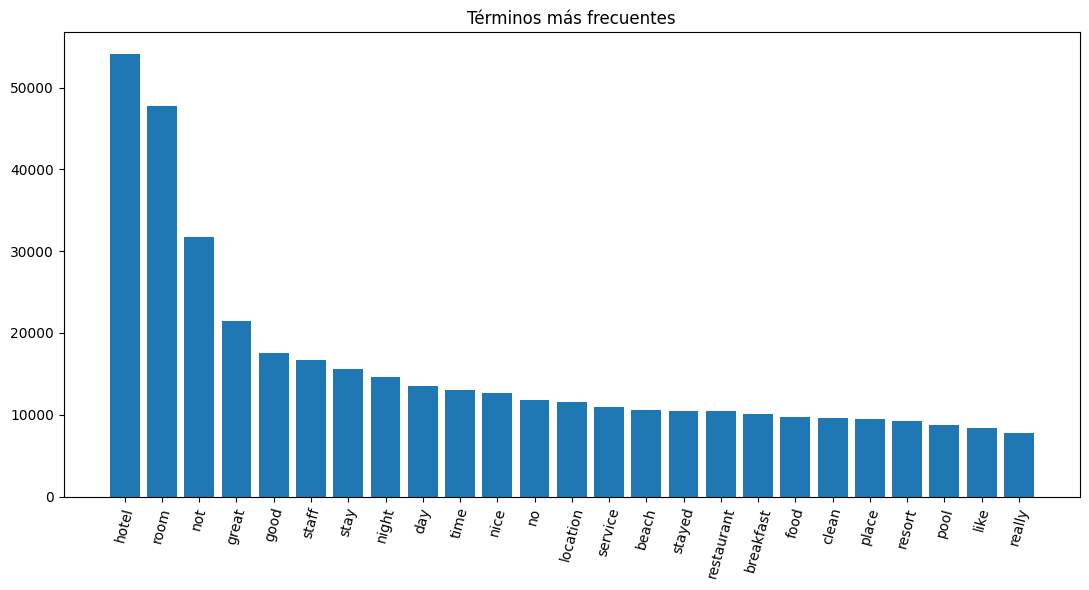

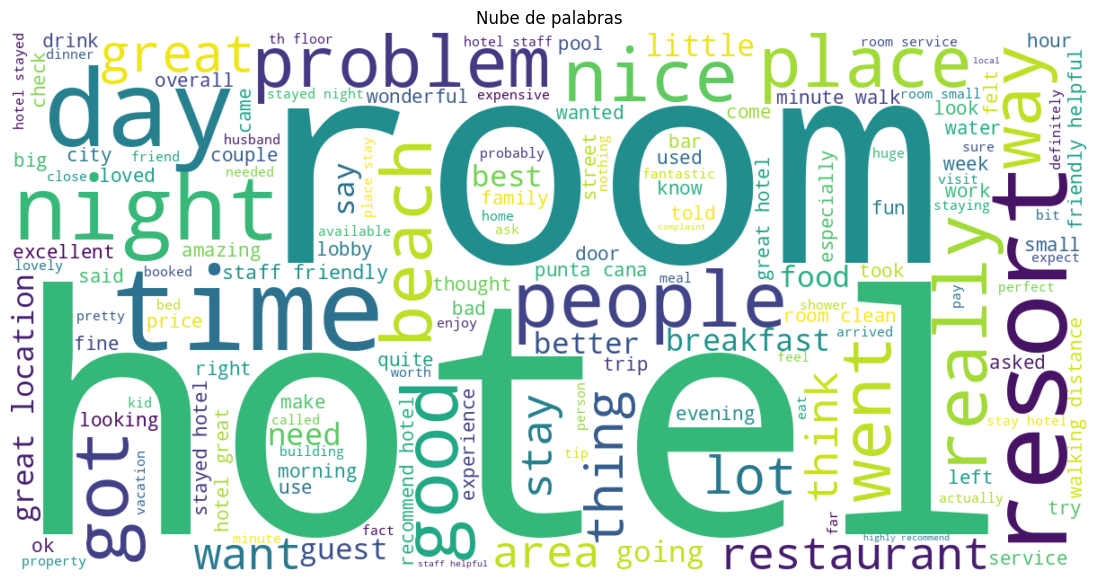

In [11]:
# Frecuencia de palabras

todos_tokens = " ".join(df["texto_limpio"]).split()
df_frecuencias = pd.DataFrame(Counter(todos_tokens).most_common(25), columns=["termino", "frecuencia"])
display(df_frecuencias)
plt.figure(figsize=(11,6)); plt.bar(df_frecuencias["termino"], df_frecuencias["frecuencia"])
plt.title("Términos más frecuentes"); plt.xticks(rotation=75); plt.tight_layout(); plt.show()

nube = WordCloud(width=1200, height=600, background_color="white", max_words=150).generate(" ".join(df["texto_limpio"]))
plt.figure(figsize=(14,7)); plt.imshow(nube, interpolation="bilinear"); plt.axis("off")
plt.title("Nube de palabras"); plt.show()

In [12]:
# Vectorización TF-IDF
# Unigramas + bigramas, hasta 5mil características

vectorizador = TfidfVectorizer(max_features=5000, min_df=5, max_df=0.90,
                                  ngram_range=(1,2), sublinear_tf=True, norm="l2")
X_tfidf = vectorizador.fit_transform(df["texto_limpio"])
nombres_terminos = np.array(vectorizador.get_feature_names_out())
print("Dimensiones de TF-IDF:", X_tfidf.shape)

Dimensiones de TF-IDF: (20491, 5000)


In [13]:
# Propiedades de los vectores

n_docs, n_vars = X_tfidf.shape
elementos_totales = n_docs * n_vars
elementos_no_cero = X_tfidf.nnz
densidad = elementos_no_cero / elementos_totales
esparsidad = 1 - densidad
normas = np.asarray(sparse_norm(X_tfidf, axis=1)).ravel()
terminos_activos = np.diff(X_tfidf.indptr)
propiedades_tfidf = pd.DataFrame({
    "propiedad": ["documentos", "características", "elementos totales", "elementos no cero",
                  "densidad", "esparsidad", "norma L2 promedio", "términos activos promedio"],
    "valor": [n_docs, n_vars, elementos_totales, elementos_no_cero, densidad, esparsidad,
              normas.mean(), terminos_activos.mean()]
})
display(propiedades_tfidf)
display(pd.Series(normas, name="norma_l2").describe().to_frame().T)
display(pd.Series(terminos_activos, name="terminos_activos").describe().to_frame().T)

,propiedad,valor
0,documentos,2.049100e+04
1,características,5.000000e+03
2,elementos totales,1.024550e+08
3,elementos no cero,1.716534e+06
4,densidad,1.675403e-02
5,esparsidad,9.832460e-01
6,norma L2 promedio,1.000000e+00
7,términos activos promedio,8.377014e+01


,count,mean,std,min,25%,50%,75%,max
norma_l2,20491.0,1.0,1.309092e-16,1.0,1.0,1.0,1.0,1.0


,count,mean,std,min,25%,50%,75%,max
terminos_activos,20491.0,83.770143,58.800778,3.0,46.0,69.0,103.0,843.0


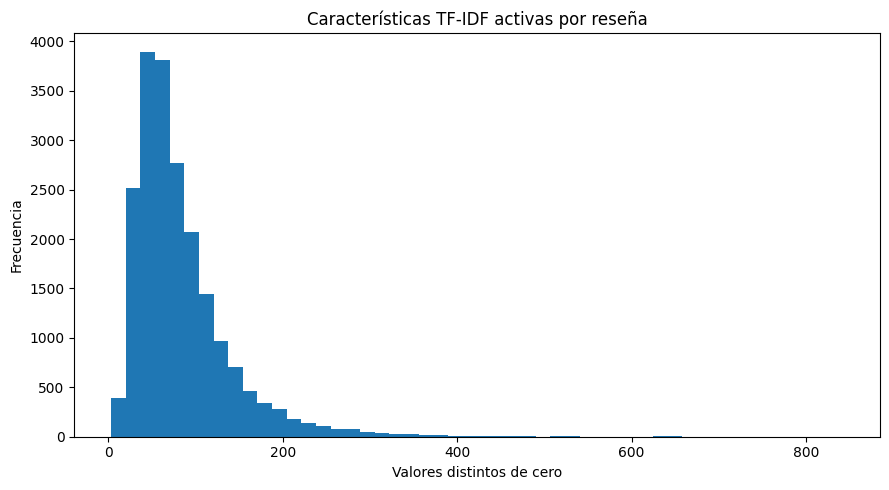

In [14]:
plt.figure(figsize=(9,5)); plt.hist(terminos_activos, bins=50)
plt.title("Características TF-IDF activas por reseña")
plt.xlabel("Valores distintos de cero"); plt.ylabel("Frecuencia")
plt.tight_layout(); plt.show()

,termino,tfidf_promedio
0,hotel,0.048607
1,room,0.041586
2,not,0.033203
3,great,0.032601
4,staff,0.027735
5,stay,0.027642
6,good,0.027068
7,location,0.025782
8,night,0.024273
9,nice,0.023379


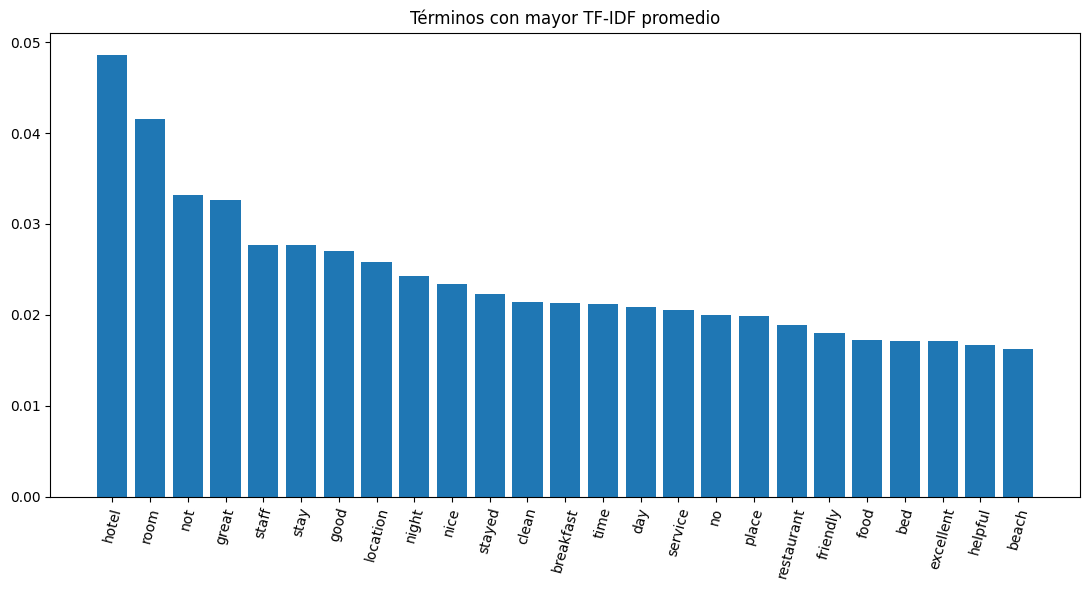

In [15]:
# Términos con mayor TF-IDF promedio

peso_global = np.asarray(X_tfidf.mean(axis=0)).ravel()
idx = peso_global.argsort()[-25:][::-1]
df_tfidf_global = pd.DataFrame({"termino": nombres_terminos[idx], "tfidf_promedio": peso_global[idx]})
display(df_tfidf_global)
plt.figure(figsize=(11,6)); plt.bar(df_tfidf_global["termino"], df_tfidf_global["tfidf_promedio"])
plt.title("Términos con mayor TF-IDF promedio"); plt.xticks(rotation=75); plt.tight_layout(); plt.show()

Negativo


,termino,tfidf_promedio
0,not,0.054749
1,room,0.046136
2,hotel,0.044849
3,no,0.036225
4,night,0.027274
5,stay,0.026967
6,day,0.025337
7,service,0.022973
8,time,0.022701
9,told,0.022277


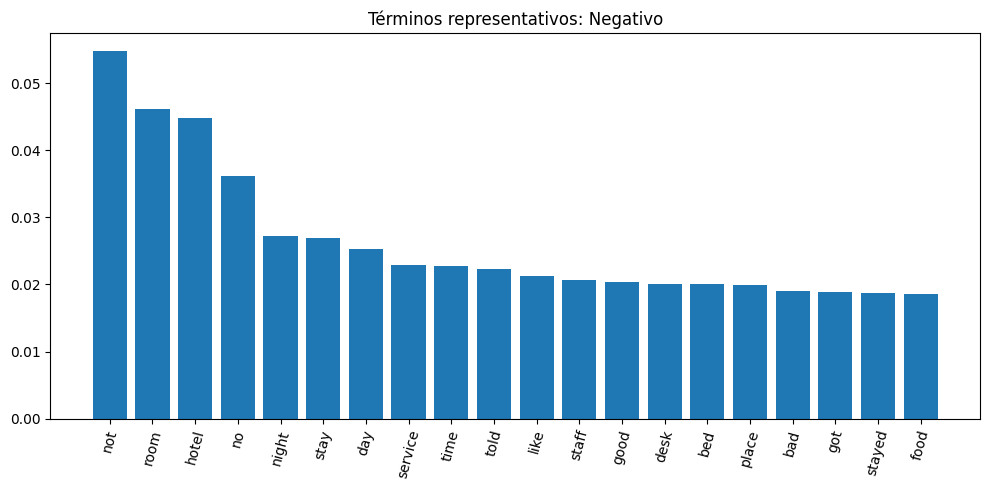

Neutral


,termino,tfidf_promedio
0,room,0.046361
1,hotel,0.045552
2,not,0.044060
3,good,0.035685
4,nice,0.029203
5,location,0.028994
6,night,0.027120
7,no,0.026268
8,clean,0.024399
9,great,0.024268


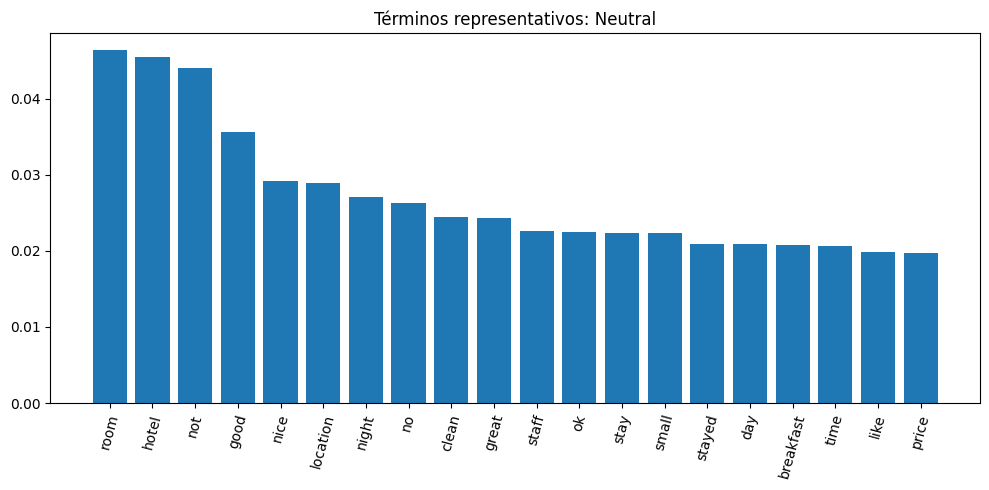

Positivo


,termino,tfidf_promedio
0,hotel,0.049849
1,room,0.039926
2,great,0.038295
3,staff,0.029971
4,stay,0.028543
5,location,0.028101
6,good,0.027258
7,not,0.027044
8,nice,0.024103
9,stayed,0.023272


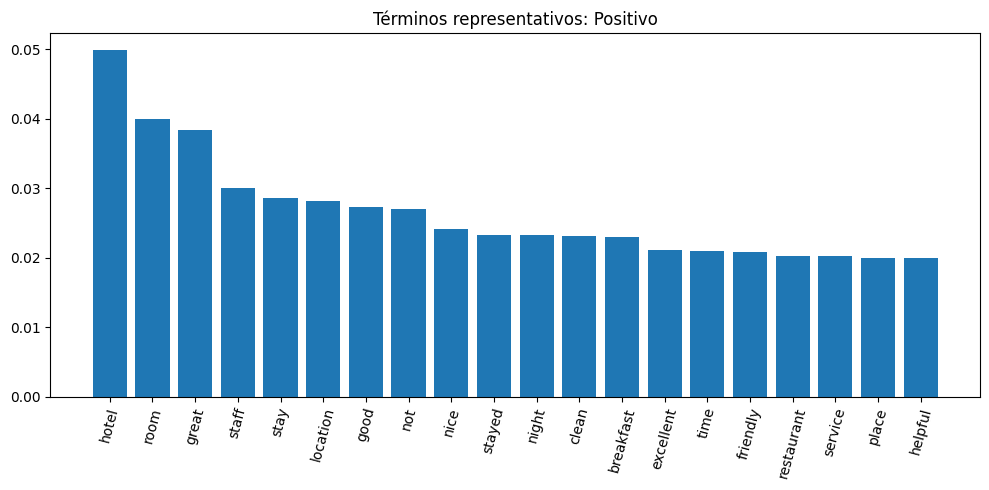

In [16]:
# Términos representativos por sentimiento

def terminos_por_clase(matriz, etiquetas, clase, nombres, n=20):
    mascara = np.asarray(etiquetas == clase)
    promedio = np.asarray(matriz[mascara].mean(axis=0)).ravel()
    posiciones = promedio.argsort()[-n:][::-1]
    return pd.DataFrame({"termino": nombres[posiciones], "tfidf_promedio": promedio[posiciones]})

tablas_terminos_clase = {}
for clase in orden_clases:
    tabla = terminos_por_clase(X_tfidf, df["sentimiento_rating"], clase, nombres_terminos)
    tablas_terminos_clase[clase] = tabla
    print(clase); display(tabla)
    plt.figure(figsize=(10,5)); plt.bar(tabla["termino"], tabla["tfidf_promedio"])
    plt.title(f"Términos representativos: {clase}"); plt.xticks(rotation=75); plt.tight_layout(); plt.show()

In [17]:
# Análisis de sentimiento con VADER: VADER se aplica al texto original.
## "compound ≥ 0.05" es positivo
## "compound ≤ -0.05" es negativo
## Los demás casos son neutrales.

sia = SentimentIntensityAnalyzer()
puntajes = df["Review"].apply(lambda x: sia.polarity_scores(str(x)))
df_vader = pd.DataFrame(puntajes.tolist())
df = pd.concat([df.reset_index(drop=True), df_vader.reset_index(drop=True)], axis=1)

def clasificar_vader(compound):
    if compound >= 0.05:
        return "Positivo"
    if compound <= -0.05:
        return "Negativo"
    return "Neutral"

df["sentimiento_vader"] = df["compound"].apply(clasificar_vader)
display(df[["Review", "Rating", "sentimiento_rating", "compound", "sentimiento_vader"]].head())

,Review,Rating,sentimiento_rating,compound,sentimiento_vader
0,"nice hotel expensive parking got good deal stay hotel anniversary, arrived late evening took advice previous reviews did valet parking, check quick easy, little disappointed non-existent view room room clean nice size, bed comfortable woke stiff ...",4,Positivo,0.9747,Positivo
1,"ok nothing special charge diamond member hilton decided chain shot 20th anniversary seattle, start booked suite paid extra website description not, suite bedroom bathroom standard hotel room, took printed reservation desk showed said things like ...",2,Negativo,0.9787,Positivo
2,"nice rooms not 4* experience hotel monaco seattle good hotel n't 4* level.positives large bathroom mediterranean suite comfortable bed pillowsattentive housekeeping staffnegatives ac unit malfunctioned stay desk disorganized, missed 3 separate wa...",3,Neutral,0.9889,Positivo
3,"unique, great stay, wonderful time hotel monaco, location excellent short stroll main downtown shopping area, pet friendly room showed no signs animal hair smells, monaco suite sleeping area big striped curtains pulled closed nice touch felt cosy...",5,Positivo,0.9912,Positivo
4,"great stay great stay, went seahawk game awesome, downfall view building did n't complain, room huge staff helpful, booked hotels website seahawk package, no charge parking got voucher taxi, problem taxi driver did n't want accept voucher barely ...",5,Positivo,0.9797,Positivo


sentimiento_vader,Negativo,Neutral,Positivo,All
sentimiento_rating,,,,
Negativo,1304,61,1849,3214
Neutral,167,13,2004,2184
Positivo,98,17,14978,15093
All,1569,91,18831,20491


Coincidencia global: 79.52%


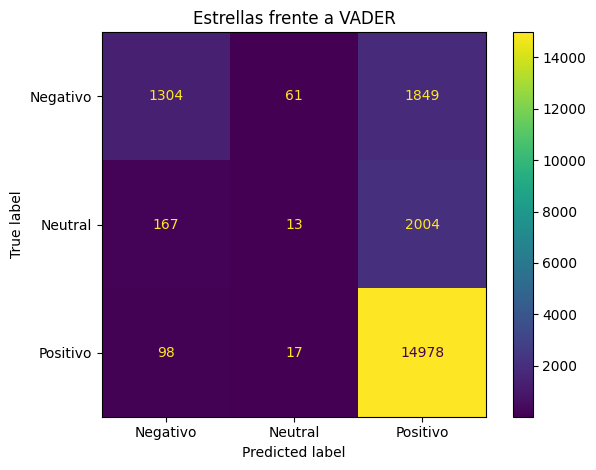

              precision    recall  f1-score   support

    Negativo       0.83      0.41      0.55      3214
     Neutral       0.14      0.01      0.01      2184
    Positivo       0.80      0.99      0.88     15093

    accuracy                           0.80     20491
   macro avg       0.59      0.47      0.48     20491
weighted avg       0.73      0.80      0.74     20491



In [18]:
# Comparación de VADER con las estrellas

tabla_cruzada = pd.crosstab(df["sentimiento_rating"], df["sentimiento_vader"], margins=True)
display(tabla_cruzada)
df["coincidencia_vader"] = df["sentimiento_rating"] == df["sentimiento_vader"]
porcentaje_coincidencia_vader = 100 * df["coincidencia_vader"].mean()
print(f"Coincidencia global: {porcentaje_coincidencia_vader:.2f}%")

matriz_vader = confusion_matrix(df["sentimiento_rating"], df["sentimiento_vader"], labels=orden_clases)
ConfusionMatrixDisplay(matriz_vader, display_labels=orden_clases).plot(values_format="d")
plt.title("Estrellas frente a VADER"); plt.tight_layout(); plt.show()
print(classification_report(df["sentimiento_rating"], df["sentimiento_vader"], labels=orden_clases, zero_division=0))

,count,mean,median,std,min,max
Rating,,,,,,
1,1421,-0.1431,-0.3818,0.7466,-0.9974,0.9976
2,1793,0.3885,0.7779,0.6897,-0.9941,0.9995
3,2184,0.7658,0.9490,0.4256,-0.9843,0.9998
4,6039,0.9346,0.9776,0.1680,-0.9467,0.9998
5,9054,0.9557,0.9828,0.1270,-0.9677,0.9999


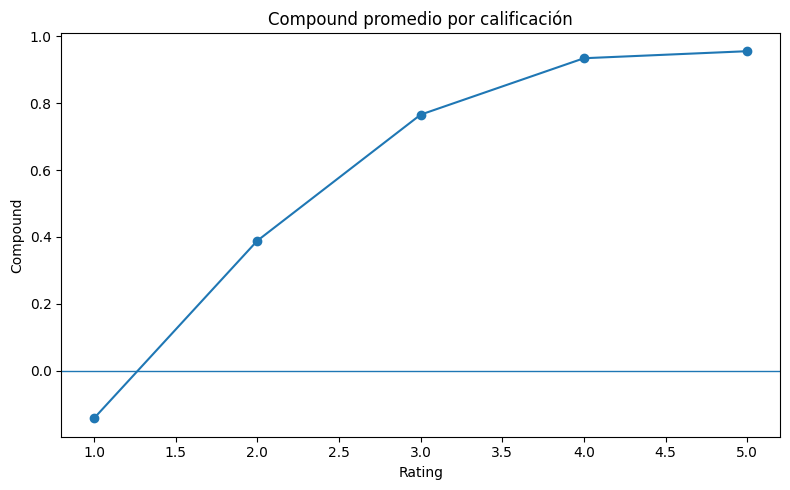

Correlación de Spearman: 0.4636


In [19]:
# Relación entre Rating y el puntaje VADER

resumen_compound = df.groupby("Rating")["compound"].agg(["count","mean","median","std","min","max"]).round(4)
display(resumen_compound)
promedio = df.groupby("Rating")["compound"].mean()
plt.figure(figsize=(8,5)); plt.plot(promedio.index, promedio.values, marker="o"); plt.axhline(0, linewidth=1)
plt.title("Compound promedio por calificación"); plt.xlabel("Rating"); plt.ylabel("Compound")
plt.tight_layout(); plt.show()
correlacion_spearman = df[["Rating","compound"]].corr(method="spearman").iloc[0,1]
print(f"Correlación de Spearman: {correlacion_spearman:.4f}")

In [20]:
# Contradicciones fuertes

contradicciones_fuertes = df[
    ((df["sentimiento_rating"]=="Positivo") & (df["sentimiento_vader"]=="Negativo")) |
    ((df["sentimiento_rating"]=="Negativo") & (df["sentimiento_vader"]=="Positivo"))
][["Review","Rating","sentimiento_rating","compound","sentimiento_vader"]].copy()
print("Número:", len(contradicciones_fuertes))
print(f"Porcentaje: {100*len(contradicciones_fuertes)/len(df):.2f}%")
display(contradicciones_fuertes.head(10))

Número: 1947
Porcentaje: 9.50%


,Review,Rating,sentimiento_rating,compound,sentimiento_vader
1,"ok nothing special charge diamond member hilton decided chain shot 20th anniversary seattle, start booked suite paid extra website description not, suite bedroom bathroom standard hotel room, took printed reservation desk showed said things like ...",2,Negativo,0.9787,Positivo
10,"poor value stayed monaco seattle july, nice hotel priced 100- 150 night not, hotel takes beating quotient, experience simply average, nothing exceptional paying 300+ n't ca n't terribly disappointed, wife stayed nicest suites 200/night felt like ...",2,Negativo,0.9666,Positivo
15,"horrible customer service hotel stay february 3rd 4th 2007my friend picked hotel monaco appealing website online package included champagne late checkout 3 free valet gift spa weekend, friend checked room hours earlier came later, pulled valet yo...",1,Negativo,0.8496,Positivo
16,"disappointed say anticipating stay hotel monaco based reviews seen tripadvisor, definitely disppointment, decor room hotel envisioned nice, housekeeping staff impressive extremely polite cheery helpful, desk bellmen standard customer service, lot...",2,Negativo,0.9905,Positivo
24,"great location need internally upgrade advantage north end downtown seattle great restaurants nearby good prices, rooms need updated literally thought sleeping 1970 bed old pillows sheets, net result bad nights sleep, stay location, staff friendly,",2,Negativo,0.9153,Positivo
32,"noise airconditioner-a standard, arranged stay travel agency unfortunately warwick seattle hotel dissapointment trip, 3 night stay warwick changed 3 rooms, starting minute stay hotel personnel didn`t make feel like guest like intruder, reluctant ...",1,Negativo,0.8716,Positivo
33,"good location poor cleanliness warwick hotel great location seattle, close shopping pike place seattle centre, really lets hotel cleanliness, bed linen torn curtains torn floor stains, hotel advertises having balcony reality disappointment, staye...",2,Negativo,0.8874,Positivo
45,"great location n't stay long needed place stay seattle prior catching early morning amtrak train portland, looked train station not, dropping hertz car hilton downtown just wanted place spend night, called hotel seattle based location tourist map...",2,Negativo,0.9829,Positivo
69,"ace grunge lives does mold mildew tiny bed metal sink cool extra instead nightsta,",1,Negativo,0.3182,Positivo
80,"priority award floor, 32 member hilton honors priority award intercontinental chain, use hilton properties chose not pay 250.00 night seattle hilton.i given gold hotel room key checkin room 32nd floor, view quite impressive good experience ended,...",2,Negativo,0.9507,Positivo


Exactitud: 0.8185
              precision    recall  f1-score   support

    Negativo       0.74      0.81      0.77       643
     Neutral       0.34      0.51      0.40       437
    Positivo       0.95      0.87      0.91      3019

    accuracy                           0.82      4099
   macro avg       0.68      0.73      0.70      4099
weighted avg       0.85      0.82      0.83      4099



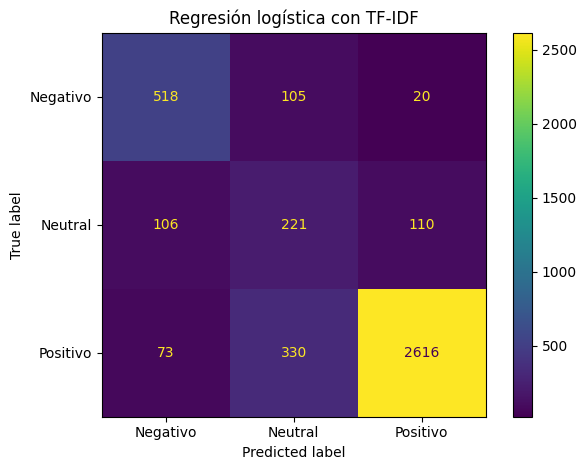

In [22]:
# Regresión logística con TF-IDF

X_train, X_test, y_train, y_test = train_test_split(
    X_tfidf, df["sentimiento_rating"], test_size=0.20, random_state=42,
    stratify=df["sentimiento_rating"])
modelo = LogisticRegression(max_iter=1500, class_weight="balanced", random_state=42)
modelo.fit(X_train, y_train)
y_pred = modelo.predict(X_test)
exactitud_modelo = accuracy_score(y_test, y_pred)
print(f"Exactitud: {exactitud_modelo:.4f}")
print(classification_report(y_test, y_pred, labels=orden_clases, zero_division=0))

matriz_modelo = confusion_matrix(y_test, y_pred, labels=orden_clases)
ConfusionMatrixDisplay(matriz_modelo, display_labels=orden_clases).plot(values_format="d")
plt.title("Regresión logística con TF-IDF"); plt.tight_layout(); plt.show()

In [23]:
# Comparación de métodos

pv, rv, fv, _ = precision_recall_fscore_support(df["sentimiento_rating"], df["sentimiento_vader"],
                                                     labels=orden_clases, average="macro", zero_division=0)
pl, rl, fl, _ = precision_recall_fscore_support(y_test, y_pred,
                                                 labels=orden_clases, average="macro", zero_division=0)
comparacion_modelos = pd.DataFrame({
    "metodo": ["VADER", "Regresión logística TF-IDF"],
    "accuracy": [accuracy_score(df["sentimiento_rating"], df["sentimiento_vader"]), exactitud_modelo],
    "precision_macro": [pv, pl], "recall_macro": [rv, rl], "f1_macro": [fv, fl]
}).round(4)
display(comparacion_modelos)

,metodo,accuracy,precision_macro,recall_macro,f1_macro
0,VADER,0.7952,0.5898,0.4680,0.4799
1,Regresión logística TF-IDF,0.8185,0.6776,0.7259,0.6950


In [24]:
# Términos influyentes del modelo

terminos_modelo = {}
for i, clase in enumerate(modelo.classes_):
    posiciones = np.argsort(modelo.coef_[i])[-20:][::-1]
    tabla = pd.DataFrame({"termino": nombres_terminos[posiciones], "coeficiente": modelo.coef_[i][posiciones]})
    terminos_modelo[clase] = tabla
    print(clase); display(tabla)

Negativo


,termino,coeficiente
0,not,3.894668
1,terrible,3.794549
2,worst,3.481256
3,dirty,3.294824
4,no,3.194091
5,rude,3.050156
6,told,3.007683
7,poor,2.625988
8,bad,2.585775
9,uncomfortable,2.261850


Neutral


,termino,coeficiente
0,ok,3.741417
1,average,3.653051
2,nothing special,2.839843
3,decent,2.348875
4,bit,2.330496
5,not bad,2.291709
6,fine,2.094274
7,rating,2.075997
8,clean,2.071385
9,nice,2.066565


Positivo


,termino,coeficiente
0,great,5.221556
1,excellent,4.195608
2,loved,4.187464
3,wonderful,3.880401
4,perfect,3.799164
5,fantastic,3.448633
6,great hotel,2.918645
7,quiet,2.615319
8,comfortable,2.541283
9,amazing,2.524685


In [25]:
# Similitud coseno entre reseñas

def buscar_resenas_similares(indice_resena, cantidad=5):
    if indice_resena < 0 or indice_resena >= len(df):
        raise IndexError(f"Índice válido: 0 a {len(df)-1}")
    similitudes = cosine_similarity(X_tfidf[indice_resena], X_tfidf).ravel()
    orden = [i for i in similitudes.argsort()[::-1] if i != indice_resena][:cantidad]
    resultado = df.loc[orden, ["Review","Rating","sentimiento_rating"]].copy()
    resultado.insert(0, "similitud_coseno", similitudes[orden])
    return resultado

indice_ejemplo = 0
print("Reseña consultada:"); display(df.loc[[indice_ejemplo], ["Review","Rating","sentimiento_rating"]])
print("Reseñas similares:"); display(buscar_resenas_similares(indice_ejemplo))

Reseña consultada:


,Review,Rating,sentimiento_rating
0,"nice hotel expensive parking got good deal stay hotel anniversary, arrived late evening took advice previous reviews did valet parking, check quick easy, little disappointed non-existent view room room clean nice size, bed comfortable woke stiff ...",4,Positivo


Reseñas similares:


,similitud_coseno,Review,Rating,sentimiento_rating
17692,0.221712,"nice clean great location noisy rooms, n't normally stay hotels nice business paid, rooms nice feature lot extras like free shoe polishing water bottle little card day temperature, room clean n't afraid walk bare feet touch bedspread, major fault...",3,Neutral
8295,0.216021,"better hotel balmes really better, excellent location shopping sights, hotel noisy night early morning maid cleaning room door woke 7am.. day water brown freshen flight fixed morning, reviews total pot luck rooms mediocre size money, view non exi...",2,Negativo
180,0.203793,"nice hotel, good check fast staff friendly, breakfast cafe good expensive.the rooms clean beds comfortable, hotel centrally located walking distance quite attractions, 12 year old son loved indoor pool, floor great views, hung night.the bad, traf...",4,Positivo
429,0.195906,"modern artsy booked hotel max weekend getaway, chose hotel travelzoo deal queen art room 139.00/night pretty good deal compared 200.00/night hotels area, parking steep 30.00/night opted park office building street, n't mind leaving car outdoors o...",3,Neutral
896,0.187906,"nice place stay stayed hotel milano oct 2004. room nice size pleasing decor comfortable bed, main drawbacks carpets hallway nasty no coffee makers rooms offer no free breakfast, coffee shops door street great pastries, location great, easy walkin...",4,Positivo


In [26]:
# Predicción de una reseña nueva

def analizar_resena_nueva(texto):
    vector = vectorizador.transform([limpiar_texto(texto)])
    puntaje = sia.polarity_scores(texto)
    clase_vader = clasificar_vader(puntaje["compound"])
    clase_modelo = modelo.predict(vector)[0]
    probabilidades = pd.DataFrame({"clase": modelo.classes_, "probabilidad": modelo.predict_proba(vector)[0]})
    print("VADER:", clase_vader, "| compound:", round(puntaje["compound"],4))
    print("Regresión logística:", clase_modelo)
    display(probabilidades.sort_values("probabilidad", ascending=False))

resena_ejemplo = "The hotel had a great location and friendly staff, but the room was not clean."
analizar_resena_nueva(resena_ejemplo)

VADER: Positivo | compound: 0.1933
Regresión logística: Neutral


,clase,probabilidad
1,Neutral,0.535378
2,Positivo,0.241924
0,Negativo,0.222698


In [27]:
# Exportación de resultados

carpeta = Path("resultados_tarea02"); carpeta.mkdir(exist_ok=True)
df.to_csv(carpeta/"resenas_procesadas.csv", index=False, encoding="utf-8-sig")
propiedades_tfidf.to_csv(carpeta/"propiedades_tfidf.csv", index=False, encoding="utf-8-sig")
df_tfidf_global.to_csv(carpeta/"terminos_tfidf_global.csv", index=False, encoding="utf-8-sig")
contradicciones_fuertes.to_csv(carpeta/"contradicciones_fuertes.csv", index=False, encoding="utf-8-sig")
comparacion_modelos.to_csv(carpeta/"comparacion_modelos.csv", index=False, encoding="utf-8-sig")
for clase, tabla in tablas_terminos_clase.items():
    tabla.to_csv(carpeta/f"terminos_tfidf_{clase.lower()}.csv", index=False, encoding="utf-8-sig")
for clase, tabla in terminos_modelo.items():
    tabla.to_csv(carpeta/f"terminos_modelo_{clase.lower()}.csv", index=False, encoding="utf-8-sig")
metricas = {"numero_resenas": int(len(df)), "caracteristicas_tfidf": int(X_tfidf.shape[1]),
            "densidad": float(densidad), "esparsidad": float(esparsidad),
            "coincidencia_vader_pct": float(porcentaje_coincidencia_vader),
            "correlacion_spearman": float(correlacion_spearman),
            "accuracy_logistica": float(exactitud_modelo),
            "contradicciones_fuertes": int(len(contradicciones_fuertes))}
with open(carpeta/"metricas_resumen.json", "w", encoding="utf-8") as f:
    json.dump(metricas, f, indent=4, ensure_ascii=False)
!zip -rq resultados_tarea02.zip resultados_tarea02
print("Se generó resultados_tarea02.zip")

Se generó resultados_tarea02.zip


In [28]:
files.download("resultados_tarea02.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>